# Bitcoin Historisk Prisanalys 2012-2026

## 1. I den här analys kommer vi kolla bitcoins pris historia genom flera intressanta grafer och diagram. 

Vi ska använda den här filen från kaggle: https://www.kaggle.com/datasets/mczielinski/bitcoin-historical-data/data  själva filen är gigantisk och täcker varje minut i bitcoins historia på en crypto börsen som heter Bitstamp, därifrån plockade autorn allt data. 

Själva filen är gigantisk över 350mb och inehåller över 7 miljoner rader, därför ska vi tvätta den och krympa till dags nivån för att få ett lätt hanterbart dataset under 1mb. 

Vi börjar med första installationer och import. 

In [1]:
# installera bibliotek

%pip install pandas numpy matplotlib seaborn --quiet

print("Done!")

Note: you may need to restart the kernel to use updated packages.
Done!


## 2. Inläsning och mekanisk inspektion

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# sökvägen till datafilen

filepath = "data/btcusd_1-min_data.csv"

# vi kollar upp dom första 5 rader i filen för bäätre överblick av strukturen
df_preview = pd.read_csv(filepath, nrows=5)
df_preview

,Timestamp,Open,High,Low,Close,Volume
0,1.325412e+09,4.58,4.58,4.58,4.58,0.0
1,1.325412e+09,4.58,4.58,4.58,4.58,0.0
2,1.325412e+09,4.58,4.58,4.58,4.58,0.0
3,1.325412e+09,4.58,4.58,4.58,4.58,0.0
4,1.325412e+09,4.58,4.58,4.58,4.58,0.0


### uptäcker direkt okänt tid format som visar sig vara unix tid i sekunder, kommer behöva normalisera det med. Jag laddar in nu hela datasetet för att undersöka och förstå datatyper som jag har, hur stort den är, och om det saknas värden. Volym borde också visa ett nummer som är märkligt bara nollor, troligtviss saknas den data i början.

In [3]:
# laddar in hela datasetet, df laddar in hela filen i minne
df = pd.read_csv("data/btcusd_1-min_data.csv")

# kollar antalet rader och kolunmer
print(f"Datasetets form (rader, kolumner): {df.shape}")

# kollar datatyper och antalet toma null värden för att hitta saknad data
df.info(show_counts=True)

Datasetets form (rader, kolumner): (7561139, 6)
<class 'pandas.DataFrame'>
RangeIndex: 7561139 entries, 0 to 7561138
Data columns (total 6 columns):
 #   Column     Non-Null Count    Dtype  
---  ------     --------------    -----  
 0   Timestamp  7561139 non-null  float64
 1   Open       7561139 non-null  float64
 2   High       7561139 non-null  float64
 3   Low        7561139 non-null  float64
 4   Close      7561139 non-null  float64
 5   Volume     7561139 non-null  float64
dtypes: float64(6)
memory usage: 346.1 MB


## 3. Datatvätt

### vi ser tydlig 7+ miljoner rader som är förväntat, inga non-null värde alla fält fyllda men jag vet från innan att det finns nollor på många ställen för volym som inte är helt rätt data eller den bara saknas från mätning i början(2012). 

Timestamp är i float64 och inte i datetime den måste konverteras med, det är lite mer komplicerat än jag trodde. Det är det som jag ska göra i nästa steg, konvertera unix tid i datetime

In [4]:
# konverterar Unix-tid som är i sekunder till ett läsbart datetime format
df['Date'] = pd.to_datetime(df['Timestamp'], unit='s')

# vi kikar på resultatet för att bekräfta att konverteringen lyckades
df[['Timestamp', 'Date', 'Close']].head()

,Timestamp,Date,Close
0,1.325412e+09,2012-01-01 10:01:00,4.58
1,1.325412e+09,2012-01-01 10:02:00,4.58
2,1.325412e+09,2012-01-01 10:03:00,4.58
3,1.325412e+09,2012-01-01 10:04:00,4.58
4,1.325412e+09,2012-01-01 10:05:00,4.58


### vi ser nu att vi har fått nytt kolumn date i taballen och det ser korrekt ut med datum 1. jan 2012. Nu den viktigaste innan vi börjar plotta grafer. 

Vi kan inte plotta så extremt stora mängder data på liten yta, inget kommer blir läsbar plus att det kan orsaka kanske att dator klarar inte av uppgiften, utan jag bestämmde att minska analys interval från minuter till dagar. Det kommer ge oss möjlughet att konvertera 350mb ursprungs storlek  till under 1bm efter downsempling. Efter detta skall vi kunna ladda upp filen(commita) på github. 

Vi skapar en ny kolumn och använder "groupby" funktion för att beräkna medelvärde för dagens pris och reducerar markant antal rader och automatisk förberedder filen till matplotlib

In [5]:
# skapar en ny kolumn som bara innehåller datumet (utan klockslag), vi avrundar en dag(många rader) med många sekunder till en bara en dag(1st rad).
df['Day'] = df['Date'].dt.floor('D')

# grupperar datan per dag och beräknar medelvärdet (mean), på så sätt vi krymper data mängd markant
df_daily = df.groupby('Day').mean(numeric_only=True).reset_index()

# kontrollerar hur mycket har vi reducerat datasetet
print(f"Ursprunglig form: {df.shape}")
print(f"Ny form efter aggregering: {df_daily.shape}")
print("\n--- Statistisk sammanfattning ---")
df_daily.describe()

Ursprunglig form: (7561139, 8)
Ny form efter aggregering: (5253, 7)

--- Statistisk sammanfattning ---


,Day,Timestamp,Open,High,Low,Close,Volume
count,5253,5.253000e+03,5253.000000,5253.000000,5253.000000,5253.000000,5253.000000
mean,2019-03-11 00:00:00,1.552306e+09,23116.295155,23124.392336,23108.026495,23116.317535,5.021150
min,2012-01-01 00:00:00,1.325437e+09,4.315465,4.315465,4.315465,4.315465,0.000000
25%,2015-08-06 00:00:00,1.438862e+09,453.303167,453.498375,453.238264,453.304771,1.339979
50%,2019-03-11 00:00:00,1.552306e+09,7903.184042,7906.308500,7899.826472,7903.280597,2.986595
75%,2022-10-14 00:00:00,1.665749e+09,37156.022917,37161.027083,37132.924993,37155.665278,6.437244
max,2026-05-19 00:00:00,1.779149e+09,124492.424306,124520.754167,124465.941667,124494.388194,88.393393
std,NaN,1.310303e+08,31190.985061,31199.377848,31182.534465,31191.012826,6.178115


### Vi har delvis uppnåt målet och minskat antal rader från över 7,5 miloner till lite över 5000. 

Säger delvis för att jag upptäckte ny fel eller anomali direkt, för datum 2026-05-19 visas felaktigt pris för btc, den ligger runt 77 000 dollar och vår dataset visar 124 000. 

Nu är jag osäkert vad det kan vara men kan inte låta bli, måste fixa det pga att det kommer ruinera visualisering senare och trots skolarbete vill jag i alla fall visa rätt data för både lärdoms och eget skull. Ska försöka filtrera bort felaktigt data. Vill hitta den nya filen och visuellt kolla var anomali börjar så att jag kan bara enkelt klippa bort dessa rader, det kanske inte är bara sista raden. 

### Nytt moment, den mindre filen hittas inte, den måste flyttas från ramminne till sdd i /data mappen.

In [6]:
# exporterar vår rensade och aggregerade tabell till en ny mindre CSV-fil i mappen /data
df_daily.to_csv("data/btcusd-daily.csv", index=False)

print("btcusd-daily.csv har sparats i /data mappen framgångsrikt!")

btcusd-daily.csv har sparats i /data mappen framgångsrikt!


### Efterson jag visuellt kollade den lilla filen så ser jag inga konstigheter värför för datumet 19. maj denna året visas bitcoins max pris, det blir liten enigma som jag låter vara nu för att göra vidare mitt uppgift. Noterar det här i readme filen med. 

## 4. Utforskning genom visualisering

### 4.1 En extremt värdeökning följd av våldsamma cykler

Den historiska utvecklingen av Bitcoin visar exakt det som rubriken påstår. Det syns en tydlig långsiktig värdeökning, men också dramatiska fall för denna otroliga tillgång. Vi kan också se att de fyraåriga cyklerna av upp och nedgångar är mycket tydliga.

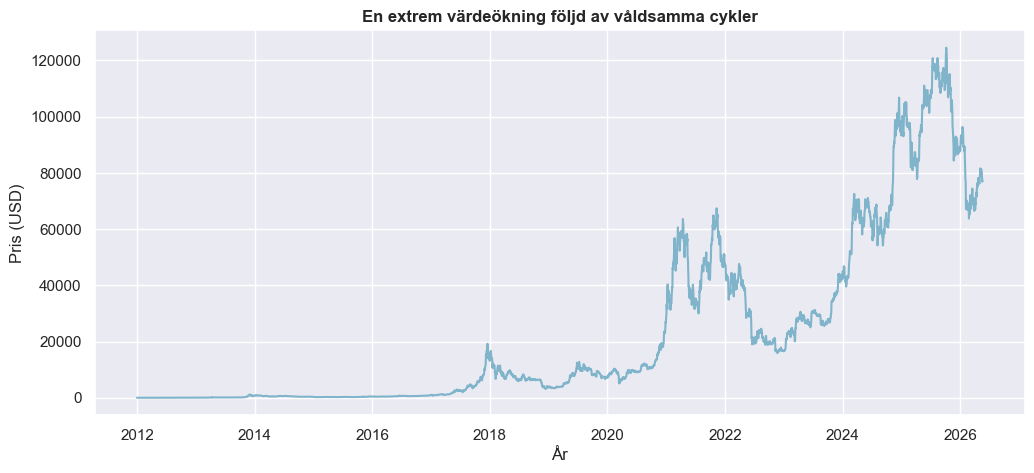

In [ ]:
# bakgrunden blir darkgrid
sns.set_theme(style="darkgrid")
# bestämmer formen av grafen och storlek
fig, ax = plt.subplots(figsize=(12, 5))
# plottning av linje, vilket kolumn ska visas, färg
ax.plot(df_daily['Day'], df_daily['Close'], color="#7fb4ca")
# snyggt titel bolderat
ax.set_title("En extrem värdeökning följd av våldsamma cykler", weight='bold')
# namnger x och y axeln och korrekt valuta
ax.set(xlabel="År", ylabel="Pris (USD)")

plt.show()